In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Этап 1. Классификация линейно неразделимых классов

- Класс 1: Эллипс (окружность), a = b = 0.3, центр (0, 0) — 60 точек
- Класс 2: Эллипс (окружность), a = b = 0.7, центр (0, 0) — 100 точек
- Класс 3: Парабола y² = 2px, p = 1, сдвиг x₀ = −0.8, y₀ = 0 — 120 точек

### 1.1 Генерация точек на кривых и случайная выборка

In [2]:
t = np.arange(0, 2 * np.pi, 0.025)

# Класс 1: окружность r=0.3
x1_all = 0.3 * np.cos(t)
y1_all = 0.3 * np.sin(t)

# Класс 2: окружность r=0.7
x2_all = 0.7 * np.cos(t)
y2_all = 0.7 * np.sin(t)

# Класс 3: парабола y^2 = 2px, p=1, x0=-0.8, y0=0
# Параметрическая форма: x = t^2/2 + x0, y = t + y0
t_par = np.arange(-2.0, 2.0, 0.025)
x3_all = t_par**2 / 2.0 - 0.8
y3_all = t_par.copy()

# Случайный выбор точек (randperm)
idx1 = np.random.permutation(len(t))[:60]
idx2 = np.random.permutation(len(t))[:100]
idx3 = np.random.permutation(len(t_par))[:120]

c1_x, c1_y = x1_all[idx1], y1_all[idx1]
c2_x, c2_y = x2_all[idx2], y2_all[idx2]
c3_x, c3_y = x3_all[idx3], y3_all[idx3]

print(f"Класс 1 (эллипс r=0.3): {len(c1_x)} точек")
print(f"Класс 2 (эллипс r=0.7): {len(c2_x)} точек")
print(f"Класс 3 (парабола):     {len(c3_x)} точек")

Класс 1 (эллипс r=0.3): 60 точек
Класс 2 (эллипс r=0.7): 100 точек
Класс 3 (парабола):     120 точек


### 1.2 Разделение на подмножества (70% — 20% — 10%)

In [3]:
def divide_rand(x, y, train_r=0.7, val_r=0.2):
    n = len(x)
    perm = np.random.permutation(n)
    n_tr = int(n * train_r)
    n_val = int(n * (train_r + val_r))
    return (x[perm[:n_tr]], y[perm[:n_tr]],
            x[perm[n_tr:n_val]], y[perm[n_tr:n_val]],
            x[perm[n_val:]], y[perm[n_val:]])

c1_tr_x, c1_tr_y, c1_vl_x, c1_vl_y, c1_ts_x, c1_ts_y = divide_rand(c1_x, c1_y)
c2_tr_x, c2_tr_y, c2_vl_x, c2_vl_y, c2_ts_x, c2_ts_y = divide_rand(c2_x, c2_y)
c3_tr_x, c3_tr_y, c3_vl_x, c3_vl_y, c3_ts_x, c3_ts_y = divide_rand(c3_x, c3_y)

for name, tr, vl, ts in [
    ("Класс 1", c1_tr_x, c1_vl_x, c1_ts_x),
    ("Класс 2", c2_tr_x, c2_vl_x, c2_ts_x),
    ("Класс 3", c3_tr_x, c3_vl_x, c3_ts_x),
]:
    print(f"{name}: train={len(tr)}, val={len(vl)}, test={len(ts)}")

Класс 1: train=42, val=11, test=7
Класс 2: train=70, val=19, test=11
Класс 3: train=84, val=23, test=13


### 1.3 Визуализация исходных множеств точек

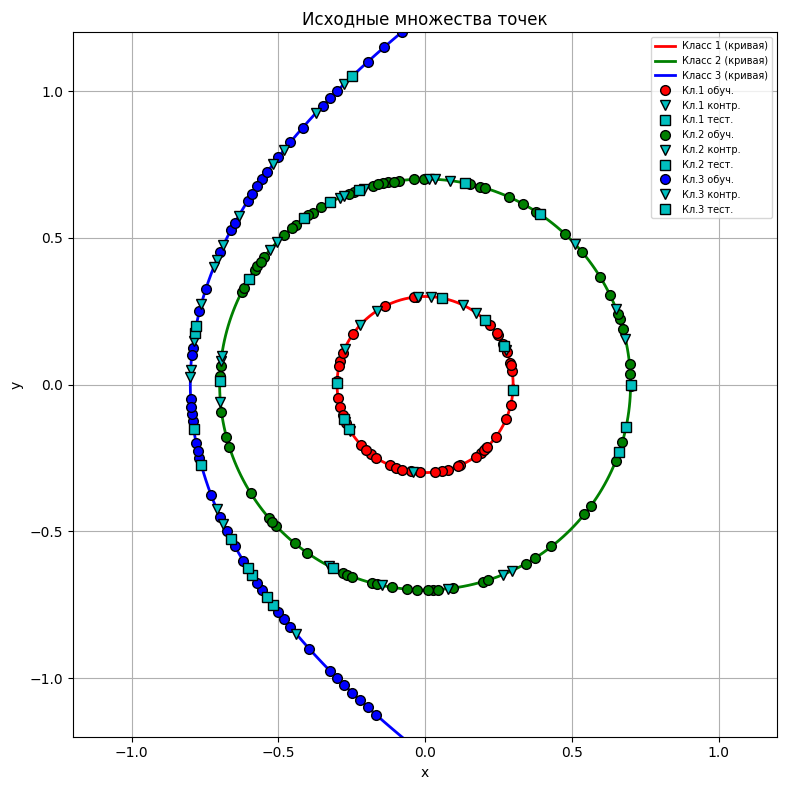

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

# Исходные кривые
ax.plot(x1_all, y1_all, '-r', linewidth=2, label='Класс 1 (кривая)')
ax.plot(x2_all, y2_all, '-g', linewidth=2, label='Класс 2 (кривая)')
ax.plot(x3_all, y3_all, '-b', linewidth=2, label='Класс 3 (кривая)')

# Класс 1: обучающее, контрольное, тестовое
ax.plot(c1_tr_x, c1_tr_y, 'o', color='r', markeredgecolor='k',
        markerfacecolor='r', markersize=7, label='Кл.1 обуч.')
ax.plot(c1_vl_x, c1_vl_y, 'v', color='r', markeredgecolor='k',
        markerfacecolor='c', markersize=7, label='Кл.1 контр.')
ax.plot(c1_ts_x, c1_ts_y, 's', color='r', markeredgecolor='k',
        markerfacecolor='c', markersize=7, label='Кл.1 тест.')

# Класс 2
ax.plot(c2_tr_x, c2_tr_y, 'o', color='g', markeredgecolor='k',
        markerfacecolor='g', markersize=7, label='Кл.2 обуч.')
ax.plot(c2_vl_x, c2_vl_y, 'v', color='g', markeredgecolor='k',
        markerfacecolor='c', markersize=7, label='Кл.2 контр.')
ax.plot(c2_ts_x, c2_ts_y, 's', color='g', markeredgecolor='k',
        markerfacecolor='c', markersize=7, label='Кл.2 тест.')

# Класс 3
ax.plot(c3_tr_x, c3_tr_y, 'o', color='b', markeredgecolor='k',
        markerfacecolor='b', markersize=7, label='Кл.3 обуч.')
ax.plot(c3_vl_x, c3_vl_y, 'v', color='b', markeredgecolor='k',
        markerfacecolor='c', markersize=7, label='Кл.3 контр.')
ax.plot(c3_ts_x, c3_ts_y, 's', color='b', markeredgecolor='k',
        markerfacecolor='c', markersize=7, label='Кл.3 тест.')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Исходные множества точек')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 1.4 Формирование обучающей выборки и целевых выходов

In [5]:
# Объединяем подмножества каждого класса
def combine_sets(*classes_data):
    """classes_data: [(tr_x, tr_y, vl_x, vl_y, ts_x, ts_y), ...]"""
    X_tr = np.column_stack([np.concatenate([c[0] for c in classes_data]),
                            np.concatenate([c[1] for c in classes_data])])
    X_vl = np.column_stack([np.concatenate([c[2] for c in classes_data]),
                            np.concatenate([c[3] for c in classes_data])])
    X_ts = np.column_stack([np.concatenate([c[4] for c in classes_data]),
                            np.concatenate([c[5] for c in classes_data])])
    return X_tr, X_vl, X_ts

def make_targets(sizes, n_classes=3):
    rows = []
    for i, n in enumerate(sizes):
        one_hot = np.zeros((n, n_classes))
        one_hot[:, i] = 1.0
        rows.append(one_hot)
    return np.vstack(rows)

cls1 = (c1_tr_x, c1_tr_y, c1_vl_x, c1_vl_y, c1_ts_x, c1_ts_y)
cls2 = (c2_tr_x, c2_tr_y, c2_vl_x, c2_vl_y, c2_ts_x, c2_ts_y)
cls3 = (c3_tr_x, c3_tr_y, c3_vl_x, c3_vl_y, c3_ts_x, c3_ts_y)

X_tr, X_vl, X_ts = combine_sets(cls1, cls2, cls3)

Y_tr = make_targets([len(c1_tr_x), len(c2_tr_x), len(c3_tr_x)])
Y_vl = make_targets([len(c1_vl_x), len(c2_vl_x), len(c3_vl_x)])
Y_ts = make_targets([len(c1_ts_x), len(c2_ts_x), len(c3_ts_x)])

# divideind — индексы для разделения
trnInd = len(X_tr)
tstInd = trnInd + len(X_vl)
proInd = tstInd + len(X_ts)

# Объединяем всё в единую обучающую выборку
X_all = np.vstack([X_tr, X_vl, X_ts])
Y_all = np.vstack([Y_tr, Y_vl, Y_ts])

# Конвертация в тензоры
X_tr_t = torch.FloatTensor(X_tr)
Y_tr_t = torch.FloatTensor(Y_tr)
X_vl_t = torch.FloatTensor(X_vl)
Y_vl_t = torch.FloatTensor(Y_vl)
X_ts_t = torch.FloatTensor(X_ts)
Y_ts_t = torch.FloatTensor(Y_ts)

print(f"Обучающее:   X={X_tr.shape}, Y={Y_tr.shape}")
print(f"Контрольное: X={X_vl.shape}, Y={Y_vl.shape}")
print(f"Тестовое:    X={X_ts.shape}, Y={Y_ts.shape}")
print(f"\ndivideInd: trainInd=1:{trnInd}, valInd={trnInd+1}:{tstInd}, testInd={tstInd+1}:{proInd}")

Обучающее:   X=(196, 2), Y=(196, 3)
Контрольное: X=(53, 2), Y=(53, 3)
Тестовое:    X=(31, 2), Y=(31, 3)

divideInd: trainInd=1:196, valInd=197:249, testInd=250:280


### 1.5–1.7 Создание и инициализация сети
- Архитектура: [2] → [20, tanh] → [3, sigmoid]
- Алгоритм обучения: RProp

In [6]:
class ClassificationNet(nn.Module):
    def __init__(self, hidden_size=20):
        super().__init__()
        self.hidden = nn.Linear(2, hidden_size)
        self.output = nn.Linear(hidden_size, 3)

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model_cls = ClassificationNet(20)
print(model_cls)
print(f"\nОбщее число параметров: {sum(p.numel() for p in model_cls.parameters())}")

ClassificationNet(
  (hidden): Linear(in_features=2, out_features=20, bias=True)
  (output): Linear(in_features=20, out_features=3, bias=True)
)

Общее число параметров: 123


### 1.8–1.9 Обучение сети
- epochs = 1500, max_fail = 1500, goal = 1e-5

In [7]:
def train_model(model, optimizer, X_tr, Y_tr, X_vl, Y_vl,
                epochs=1500, max_fail=1500, goal=1e-5,
                use_lbfgs=False, verbose_step=200):
    """Обучение с ранней остановкой по контрольному подмножеству."""
    criterion = nn.MSELoss()
    best_val = float('inf')
    fails = 0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    hist_tr, hist_vl = [], []

    for ep in range(1, epochs + 1):
        model.train()
        if use_lbfgs:
            def closure():
                optimizer.zero_grad()
                loss = criterion(model(X_tr), Y_tr)
                loss.backward()
                return loss
            tr_loss = optimizer.step(closure).item()
        else:
            optimizer.zero_grad()
            loss = criterion(model(X_tr), Y_tr)
            loss.backward()
            optimizer.step()
            tr_loss = loss.item()

        model.eval()
        with torch.no_grad():
            vl_loss = criterion(model(X_vl), Y_vl).item()

        hist_tr.append(tr_loss)
        hist_vl.append(vl_loss)

        if vl_loss < best_val:
            best_val = vl_loss
            fails = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            fails += 1

        if tr_loss <= goal:
            print(f"Эпоха {ep}: цель достигнута, MSE = {tr_loss:.2e}")
            break
        if fails >= max_fail:
            print(f"Эпоха {ep}: ранняя остановка (max_fail={max_fail})")
            break
        if ep % verbose_step == 0:
            print(f"Эпоха {ep}: train={tr_loss:.6f}, val={vl_loss:.6f}")

    if ep == epochs and tr_loss > goal and fails < max_fail:
        print(f"Эпоха {ep}: обучение завершено, train_MSE={tr_loss:.6e}")

    model.load_state_dict(best_state)
    return hist_tr, hist_vl

Эпоха 200: train=0.013430, val=0.026883
Эпоха 400: train=0.003171, val=0.010777
Эпоха 600: train=0.000472, val=0.004568
Эпоха 800: train=0.000054, val=0.006618
Эпоха 979: цель достигнута, MSE = 9.99e-06


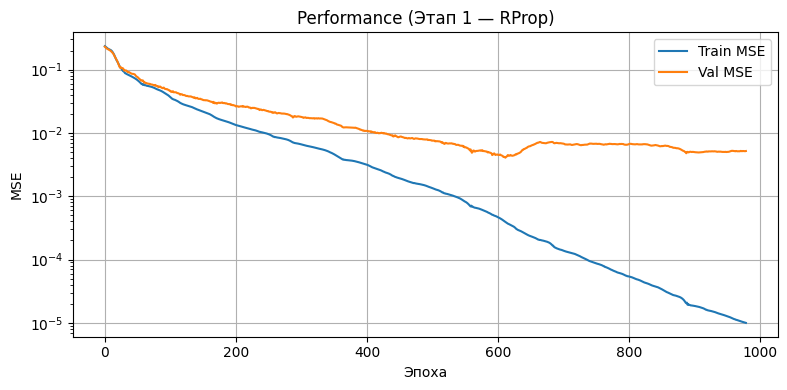

In [8]:
torch.manual_seed(42)
model_cls = ClassificationNet(20)
optimizer_cls = torch.optim.Rprop(model_cls.parameters())

hist_tr1, hist_vl1 = train_model(
    model_cls, optimizer_cls,
    X_tr_t, Y_tr_t, X_vl_t, Y_vl_t,
    epochs=1500, max_fail=1500, goal=1e-5
)

# График обучения (Performance)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hist_tr1, label='Train MSE')
ax.semilogy(hist_vl1, label='Val MSE')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE')
ax.set_title('Performance (Этап 1 — RProp)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 1.10 Структура сети и параметры обучения

In [9]:
print("=== Структура сети (Этап 1) ===")
print(f"Тип сети:            feedforwardnet (многослойная прямого распространения)")
print(f"Архитектура:         [2] -> [20, tansig] -> [3, sigmoid]")
print(f"Алгоритм обучения:   RProp (trainrp)")
print(f"Параметры обучения:  epochs=1500, max_fail=1500, goal=1e-5")
print(f"Всего эпох обучения: {len(hist_tr1)}")
print(f"Финальная MSE train: {hist_tr1[-1]:.6e}")
print(f"Финальная MSE val:   {hist_vl1[-1]:.6e}")
print()
for name, param in model_cls.named_parameters():
    print(f"{name}: shape={list(param.shape)}")
    print(param.data.numpy().round(4))
    print()

=== Структура сети (Этап 1) ===
Тип сети:            feedforwardnet (многослойная прямого распространения)
Архитектура:         [2] -> [20, tansig] -> [3, sigmoid]
Алгоритм обучения:   RProp (trainrp)
Параметры обучения:  epochs=1500, max_fail=1500, goal=1e-5
Всего эпох обучения: 979
Финальная MSE train: 9.988631e-06
Финальная MSE val:   5.174015e-03

hidden.weight: shape=[20, 2]
[[ 1.03490e+00  1.56260e+00]
 [-1.83410e+00  1.05732e+01]
 [-1.01112e+01 -6.92200e-01]
 [-8.05030e+00  4.67910e+00]
 [ 1.87430e+00 -2.33510e+00]
 [-9.30000e-03  4.06000e-02]
 [ 1.92540e+00  2.25210e+00]
 [ 2.83000e-02 -7.05000e-02]
 [ 7.00000e-03 -2.77000e-02]
 [-1.59300e-01  7.64000e-02]
 [ 1.14000e-02  5.69000e-02]
 [-1.24000e-02 -6.03000e-02]
 [ 3.70000e-02  1.65000e-02]
 [ 2.44900e+00 -2.71750e+00]
 [ 1.21270e+00 -2.45640e+00]
 [ 1.42330e+00 -1.05734e+01]
 [ 6.02800e-01  1.05520e+00]
 [ 8.25800e-01  1.05220e+00]
 [ 6.12350e+00  7.41390e+00]
 [ 1.04300e-01  1.40000e-03]]

hidden.bias: shape=[20]
[ 1.2449 -3

### 1.11–1.12 Оценка качества классификации
Порог: oij = 1 если aij > 0.5, иначе 0

In [10]:
def evaluate_cls(model, X, Y, name=""):
    model.eval()
    with torch.no_grad():
        out = model(X)
    pred = (out > 0.5).float()
    correct = (pred == Y).all(dim=1).sum().item()
    total = Y.shape[0]
    print(f"{name}: {correct}/{total} правильно классифицировано ({100*correct/total:.1f}%)")
    return pred

print("--- Результаты классификации ---")
pred_tr = evaluate_cls(model_cls, X_tr_t, Y_tr_t, "Обучающее")
pred_vl = evaluate_cls(model_cls, X_vl_t, Y_vl_t, "Контрольное")
pred_ts = evaluate_cls(model_cls, X_ts_t, Y_ts_t, "Тестовое")

--- Результаты классификации ---
Обучающее: 196/196 правильно классифицировано (100.0%)
Контрольное: 52/53 правильно классифицировано (98.1%)
Тестовое: 31/31 правильно классифицировано (100.0%)


### 1.13–1.14 Классификация области [−1.2, 1.2] × [−1.2, 1.2]
Шаг сетки h = 0.025. Каждая компонента выходного вектора задаёт интенсивность одного из цветов RGB:
- (1, 0, 0) — красный (класс 1)
- (0, 1, 0) — зелёный (класс 2)
- (0, 0, 1) — синий (класс 3)

Таблица цветов (189 уникальных):
  0: RGB = [0. 0. 0.]
  1: RGB = [0.  0.  0.1]
  2: RGB = [0.  0.  0.3]
  3: RGB = [0.  0.  0.4]
  4: RGB = [0.  0.  0.5]
  5: RGB = [0.  0.  0.6]
  6: RGB = [0.  0.  0.7]
  7: RGB = [0.  0.  0.8]
  8: RGB = [0.  0.  0.9]
  9: RGB = [0. 0. 1.]
  10: RGB = [0.  0.1 0. ]
  11: RGB = [0.  0.1 0.1]
  12: RGB = [0.  0.1 0.2]
  13: RGB = [0.  0.1 0.3]
  14: RGB = [0.  0.1 0.4]
  15: RGB = [0.  0.1 0.5]
  16: RGB = [0.  0.1 0.6]
  17: RGB = [0.  0.1 0.7]
  18: RGB = [0.  0.1 0.8]
  19: RGB = [0.  0.1 0.9]
  20: RGB = [0.  0.1 1. ]
  21: RGB = [0.  0.2 0. ]
  22: RGB = [0.  0.2 0.1]
  23: RGB = [0.  0.2 0.2]
  24: RGB = [0.  0.2 0.3]
  25: RGB = [0.  0.2 0.4]
  26: RGB = [0.  0.2 0.5]
  27: RGB = [0.  0.2 0.7]
  28: RGB = [0.  0.2 0.8]
  29: RGB = [0.  0.2 0.9]
  30: RGB = [0.  0.2 1. ]
  31: RGB = [0.  0.3 0. ]
  32: RGB = [0.  0.3 0.1]
  33: RGB = [0.  0.3 0.2]
  34: RGB = [0.  0.3 0.3]
  35: RGB = [0.  0.3 0.5]
  36: RGB = [0.  0.3 0.6]
  37: RGB = [0.  0.3 

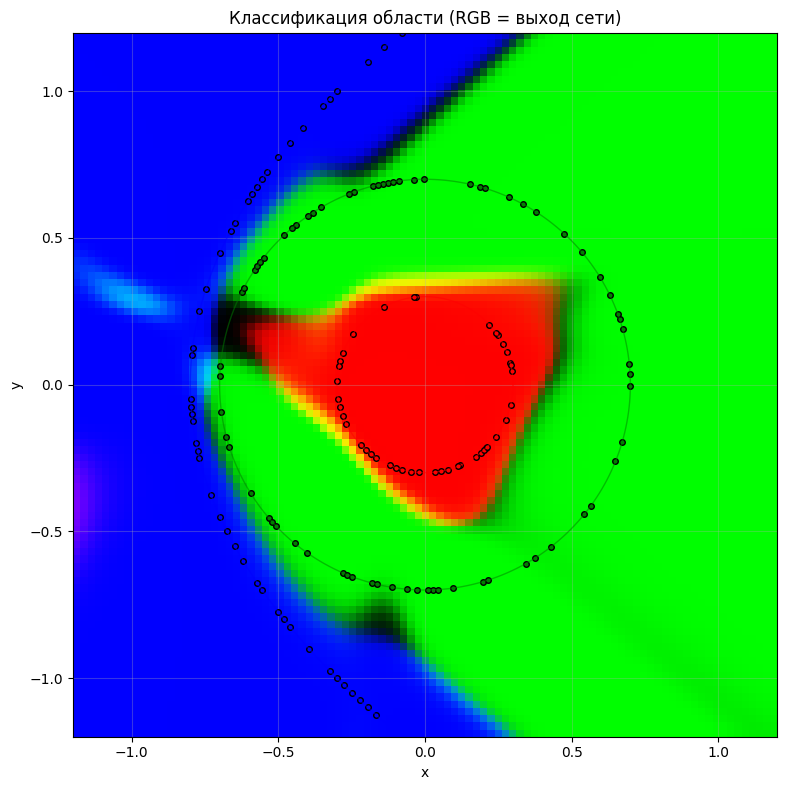

In [11]:
h = 0.025
grid_vals = np.arange(-1.2, 1.2 + h, h)
gx, gy = np.meshgrid(grid_vals, grid_vals)
grid_pts = torch.FloatTensor(np.column_stack([gx.ravel(), gy.ravel()]))

model_cls.eval()
with torch.no_grad():
    grid_out = model_cls(grid_pts).numpy()

# Округляем до десятых для формирования таблицы цветов
grid_rounded = np.round(grid_out, 1)
# Уникальные цвета (colormap)
unique_colors = np.unique(grid_rounded, axis=0)
print(f"Таблица цветов ({len(unique_colors)} уникальных):")
for i, c in enumerate(unique_colors):
    print(f"  {i}: RGB = {c}")

# Формируем RGB-изображение из выхода сети
grid_rgb = np.clip(grid_out, 0, 1).reshape(gx.shape[0], gx.shape[1], 3)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grid_rgb, extent=[-1.2, 1.2, -1.2, 1.2], origin='lower', aspect='equal')

# Наложение точек обучающей выборки
ax.plot(c1_tr_x, c1_tr_y, 'o', markeredgecolor='k', markerfacecolor='r', markersize=4)
ax.plot(c2_tr_x, c2_tr_y, 'o', markeredgecolor='k', markerfacecolor='g', markersize=4)
ax.plot(c3_tr_x, c3_tr_y, 'o', markeredgecolor='k', markerfacecolor='b', markersize=4)

# Исходные кривые
ax.plot(x1_all, y1_all, 'r-', linewidth=1, alpha=0.5)
ax.plot(x2_all, y2_all, 'g-', linewidth=1, alpha=0.5)
ax.plot(x3_all, y3_all, 'b-', linewidth=1, alpha=0.5)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Классификация области (RGB = выход сети)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Этап 2. Аппроксимация функции (метод первого порядка)
- Функция: x = cos(t² − 2t + 3), t ∈ [0, 5], h = 0.02
- Метод обучения: **traingdx** (градиентный спуск с адаптивным шагом и моментом)
- lr = 0.05, lr_inc = 1.05, mc = 0.9
- Архитектура: [1] → [10, tansig] → [1, purelin]

### 2.1 Подготовка данных

Всего точек: 251
Обучающее: 226, контрольное: 25
Вход нормализован: mean=2.50, std=1.45
X_train диапазон: [-1.73, 1.38]


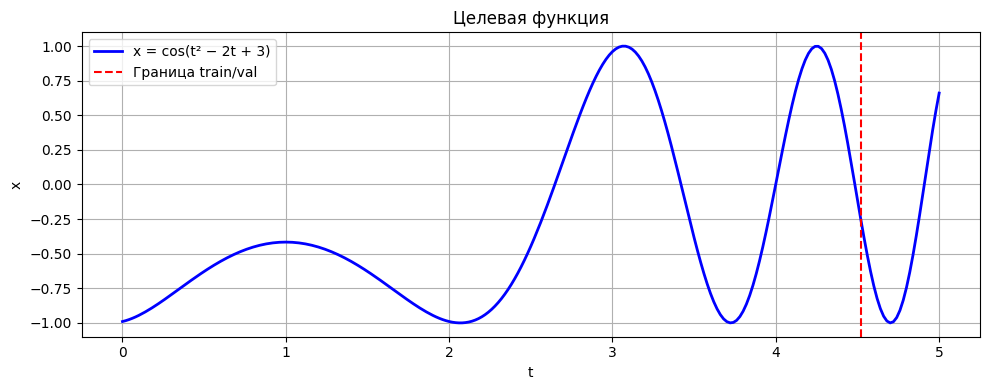

In [12]:
t_func = np.arange(0, 5 + 0.02, 0.02)
y_func = np.cos(t_func**2 - 2 * t_func + 3)

n_total = len(t_func)
n_val_f = int(n_total * 0.1)   # 10% с конца — контрольное
n_train_f = n_total - n_val_f

# Разделение: первые 90% — обучающее, последние 10% — контрольное
t_train, y_train_f = t_func[:n_train_f], y_func[:n_train_f]
t_val, y_val_f = t_func[n_train_f:], y_func[n_train_f:]

print(f"Всего точек: {n_total}")
print(f"Обучающее: {n_train_f}, контрольное: {n_val_f}")

# Нормализация входа в [-1, 1] для лучшей работы SGD
t_mean = t_func.mean()
t_std = t_func.std()

X_train_f = torch.FloatTensor((t_train - t_mean) / t_std).unsqueeze(1)
Y_train_f = torch.FloatTensor(y_train_f).unsqueeze(1)
X_val_f = torch.FloatTensor((t_val - t_mean) / t_std).unsqueeze(1)
Y_val_f = torch.FloatTensor(y_val_f).unsqueeze(1)

print(f"Вход нормализован: mean={t_mean:.2f}, std={t_std:.2f}")
print(f"X_train диапазон: [{X_train_f.min().item():.2f}, {X_train_f.max().item():.2f}]")

# График целевой функции
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_func, y_func, 'b-', linewidth=2, label='x = cos(t² − 2t + 3)')
ax.axvline(t_func[n_train_f], color='r', linestyle='--', label='Граница train/val')
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title('Целевая функция')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 2.1–2.5 Создание сети и обучение (traingdx)

In [13]:
class ApproxNet(nn.Module):
    def __init__(self, hidden_size=10):
        super().__init__()
        self.hidden = nn.Linear(1, hidden_size)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = self.output(x)
        return x


def train_gdx(model, X_tr, Y_tr, X_vl, Y_vl,
                lr=0.05, momentum=0.9, lr_inc=1.05, lr_dec=0.7,
                epochs=600, max_fail=600, goal=1e-8):
    """Обучение методом градиентного спуска с адаптивным шагом и моментом (traingdx)."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    best_val = float('inf')
    fails = 0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    prev_state = {k: v.clone() for k, v in model.state_dict().items()}
    prev_loss = float('inf')
    hist_tr, hist_vl = [], []

    for ep in range(1, epochs + 1):
        prev_state = {k: v.clone() for k, v in model.state_dict().items()}

        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), Y_tr)
        loss.backward()
        optimizer.step()
        tr_loss = loss.item()

        # Адаптивный шаг обучения (traingdx)
        if tr_loss > prev_loss * 1.04:
            model.load_state_dict(prev_state)
            for pg in optimizer.param_groups:
                pg['lr'] = max(pg['lr'] * lr_dec, 1e-7)
            tr_loss = prev_loss
        elif tr_loss < prev_loss:
            for pg in optimizer.param_groups:
                pg['lr'] = min(pg['lr'] * lr_inc, 1.0)
        prev_loss = tr_loss

        model.eval()
        with torch.no_grad():
            vl_loss = criterion(model(X_vl), Y_vl).item()

        hist_tr.append(tr_loss)
        hist_vl.append(vl_loss)

        if vl_loss < best_val:
            best_val = vl_loss
            fails = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            fails += 1

        if tr_loss <= goal:
            print(f"Эпоха {ep}: достигнута цель MSE <= {goal}")
            break
        if fails >= max_fail:
            print(f"Эпоха {ep}: ранняя остановка (max_fail={max_fail})")
            break

    model.load_state_dict(best_state)
    return hist_tr, hist_vl

In [14]:
# Обучение несколько раз с перебором параметров
best_loss_gdx = float('inf')
best_state_gdx = None
best_hist_gdx = None
best_cfg = ""

for n_hidden in [15, 20, 25, 30]:
    for seed in range(20):
        torch.manual_seed(seed)
        m = ApproxNet(n_hidden)
        
        h_tr, h_vl = train_gdx(m, X_train_f, Y_train_f, X_val_f, Y_val_f,
                                lr=0.05, momentum=0.9, lr_inc=1.05, lr_dec=0.7,
                                epochs=10000, max_fail=10000, goal=1e-8)
        final = h_tr[-1]
        if final < best_loss_gdx:
            best_loss_gdx = final
            best_state_gdx = {k: v.clone() for k, v in m.state_dict().items()}
            best_hist_gdx = (h_tr, h_vl)
            best_cfg = f"hidden={n_hidden}, seed={seed}"
            print(f"  * NEW BEST: {best_cfg}, MSE = {final:.6e}")

print(f"\nЛучший результат: {best_cfg}, train_MSE = {best_loss_gdx:.6e}")
model_gdx = ApproxNet(int(best_cfg.split("=")[1].split(",")[0]))
model_gdx.load_state_dict(best_state_gdx)
hist_tr2, hist_vl2 = best_hist_gdx

  * NEW BEST: hidden=15, seed=0, MSE = 2.321588e-01
  * NEW BEST: hidden=15, seed=18, MSE = 2.270775e-01

Лучший результат: hidden=15, seed=18, train_MSE = 2.270775e-01


### 2.5–2.6 Структура сети и весовые коэффициенты

Эпох обучения:       10000
Финальная MSE train: 2.270775e-01
Финальная MSE val:   7.607433e-01

--- Весовые коэффициенты ---
hidden.weight: shape=[15, 1]
[[-0.0186]
 [-0.0923]
 [-0.1894]
 [ 0.5149]
 [ 0.9437]
 [ 0.1965]
 [ 0.1216]
 [ 0.0997]
 [-0.5819]
 [-0.548 ]
 [-1.0301]
 [ 2.7358]
 [ 0.0374]
 [-0.3784]
 [ 0.9367]]

hidden.bias: shape=[15]
[ 0.3819  0.5484  0.0023 -0.4694  0.1796  0.472   0.5289  0.7988 -0.9801
 -0.0534 -0.4852  0.1004  0.7483  0.1402  0.3706]

output.weight: shape=[1, 15]
[[-0.1311 -0.2001  0.1312 -0.1943 -0.0849 -0.084   0.1504 -0.0304 -0.1268
  -0.057   0.2788  0.9548 -0.147  -0.0299 -0.3251]]

output.bias: shape=[1]
[-0.1227]



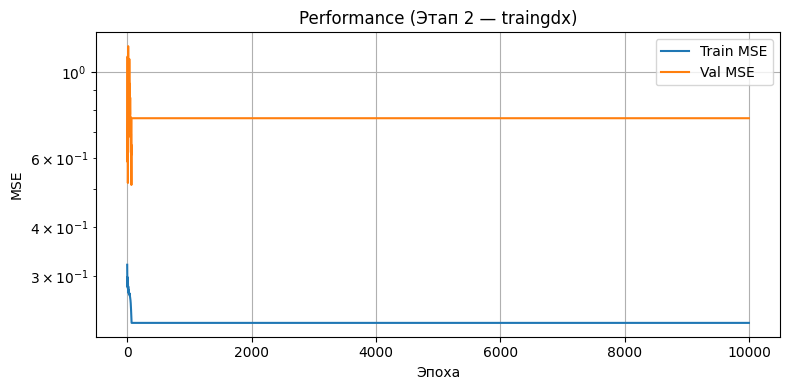

In [15]:
print(f"Эпох обучения:       {len(hist_tr2)}")
print(f"Финальная MSE train: {hist_tr2[-1]:.6e}")
print(f"Финальная MSE val:   {hist_vl2[-1]:.6e}")
print()
print("--- Весовые коэффициенты ---")
for name, param in model_gdx.named_parameters():
    print(f"{name}: shape={list(param.shape)}")
    print(param.data.numpy().round(4))
    print()

# Performance
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hist_tr2, label='Train MSE')
ax.semilogy(hist_vl2, label='Val MSE')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE')
ax.set_title('Performance (Этап 2 — traingdx)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 2.7–2.8 Оценка качества аппроксимации

Обучающее:
  MSE = 2.270775e-01
  MAE = 3.750812e-01
  Max|err| = 1.160193e+00
  R²  = 0.441526

Контрольное:
  MSE = 5.129018e-01
  MAE = 6.465099e-01
  Max|err| = 1.049366e+00
  R²  = -1.049976


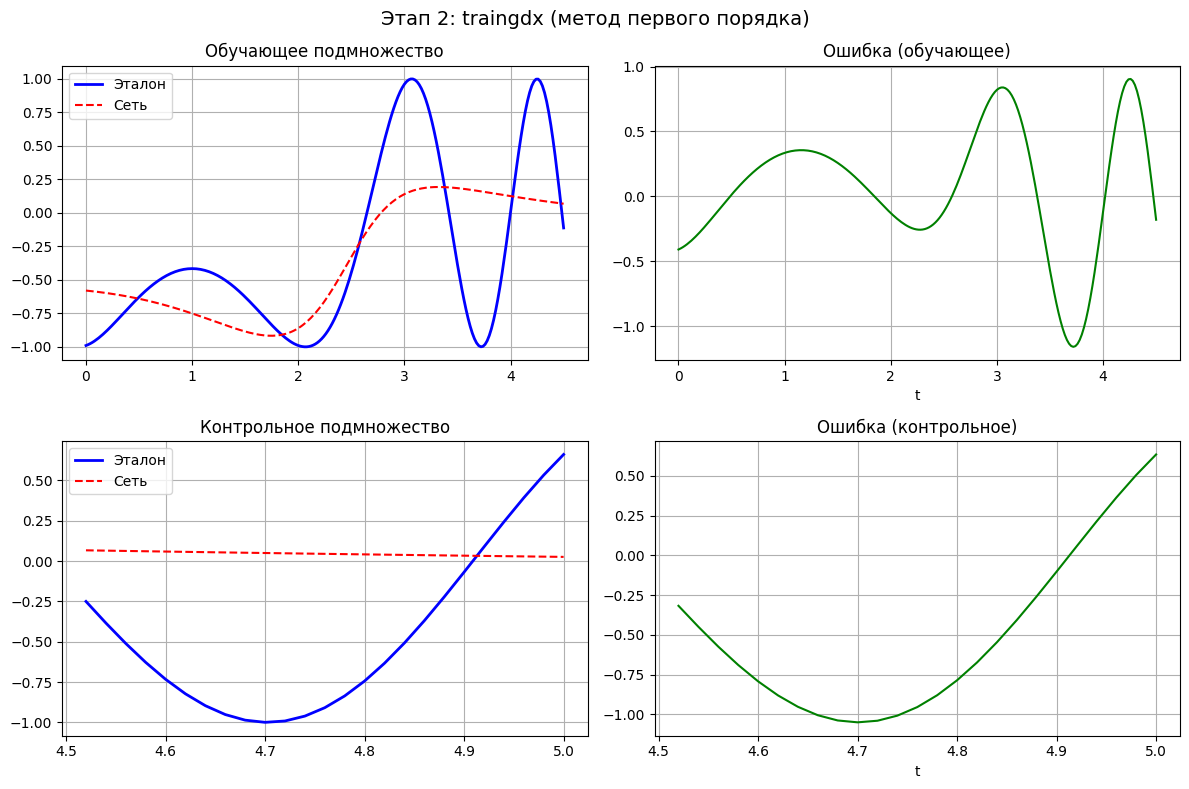

In [16]:
def evaluate_approx(model, X_data, Y_data, name=""):
    model.eval()
    with torch.no_grad():
        pred = model(X_data).numpy().flatten()
    target = Y_data.numpy().flatten()
    err = target - pred
    mse = np.mean(err**2)
    mae = np.mean(np.abs(err))
    max_err = np.max(np.abs(err))
    ss_res = np.sum(err**2)
    ss_tot = np.sum((target - target.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    print(f"{name}:")
    print(f"  MSE = {mse:.6e}")
    print(f"  MAE = {mae:.6e}")
    print(f"  Max|err| = {max_err:.6e}")
    print(f"  R²  = {r2:.6f}")
    return pred, err

# Обучающее подмножество
pred_tr2, err_tr2 = evaluate_approx(model_gdx, X_train_f, Y_train_f, "Обучающее")
print()
# Контрольное подмножество
pred_vl2, err_vl2 = evaluate_approx(model_gdx, X_val_f, Y_val_f, "Контрольное")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(t_train, y_train_f, 'b-', linewidth=2, label='Эталон')
axes[0, 0].plot(t_train, pred_tr2, 'r--', linewidth=1.5, label='Сеть')
axes[0, 0].set_title('Обучающее подмножество')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(t_train, err_tr2, 'g-')
axes[0, 1].set_title('Ошибка (обучающее)')
axes[0, 1].set_xlabel('t')
axes[0, 1].grid(True)

axes[1, 0].plot(t_val, y_val_f, 'b-', linewidth=2, label='Эталон')
axes[1, 0].plot(t_val, pred_vl2, 'r--', linewidth=1.5, label='Сеть')
axes[1, 0].set_title('Контрольное подмножество')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(t_val, err_vl2, 'g-')
axes[1, 1].set_title('Ошибка (контрольное)')
axes[1, 1].set_xlabel('t')
axes[1, 1].grid(True)

plt.suptitle('Этап 2: traingdx (метод первого порядка)', fontsize=14)
plt.tight_layout()
plt.show()

## Этап 3. Аппроксимация функции (метод второго порядка)
- Функция: x = cos(t² − 2t + 3), t ∈ [0, 5], h = 0.02
- Метод обучения: **trainbfg** (квазиньютоновский метод BFGS)
- Архитектура: [1] → [10, tansig] → [1, purelin]

### 3.1–3.5 Создание сети и обучение (trainbfg / LBFGS)

In [17]:
# Обучение LBFGS — без ранней остановки, чтобы показать мощь метода 2-го порядка
best_loss_bfg = float('inf')
best_state_bfg = None
best_hist_bfg = None
best_cfg_bfg = ""

criterion_bfg = nn.MSELoss()

for n_hidden in [10, 15, 20, 25]:
    for seed in range(15):
        torch.manual_seed(seed)
        m = ApproxNet(n_hidden)
        opt = torch.optim.LBFGS(m.parameters(), lr=0.1,
                                max_iter=20, line_search_fn='strong_wolfe')
        
        h_tr, h_vl = [], []
        for ep in range(1, 601):
            m.train()
            def closure():
                opt.zero_grad()
                loss = criterion_bfg(m(X_train_f), Y_train_f)
                loss.backward()
                return loss
            tr_loss = opt.step(closure).item()
            
            m.eval()
            with torch.no_grad():
                vl_loss = criterion_bfg(m(X_val_f), Y_val_f).item()
            h_tr.append(tr_loss)
            h_vl.append(vl_loss)
            
            if tr_loss <= 1e-8:
                break
        
        final_tr = h_tr[-1]
        if final_tr < best_loss_bfg:
            best_loss_bfg = final_tr
            best_state_bfg = {k: v.clone() for k, v in m.state_dict().items()}
            best_hist_bfg = (h_tr, h_vl)
            best_cfg_bfg = f"hidden={n_hidden}, seed={seed}"
            print(f"  * NEW BEST: {best_cfg_bfg}, tr_MSE = {final_tr:.6e}")

print(f"\nЛучший результат: {best_cfg_bfg}, train_MSE = {best_loss_bfg:.6e}")
model_bfg = ApproxNet(int(best_cfg_bfg.split("=")[1].split(",")[0]))
model_bfg.load_state_dict(best_state_bfg)
hist_tr3, hist_vl3 = best_hist_bfg

  * NEW BEST: hidden=10, seed=0, tr_MSE = 1.261688e-05
  * NEW BEST: hidden=10, seed=3, tr_MSE = 4.426003e-06
  * NEW BEST: hidden=10, seed=9, tr_MSE = 1.482312e-06
  * NEW BEST: hidden=10, seed=13, tr_MSE = 7.655516e-07

Лучший результат: hidden=10, seed=13, train_MSE = 7.655516e-07


### 3.5–3.6 Структура сети и весовые коэффициенты

Эпох обучения:       600
Финальная MSE train: 7.655516e-07
Финальная MSE val:   1.950735e+00

--- Весовые коэффициенты ---
hidden.weight: shape=[10, 1]
[[-3.4109]
 [ 3.1201]
 [ 1.6499]
 [-3.1128]
 [-1.8725]
 [ 3.2658]
 [ 4.4003]
 [ 3.5613]
 [ 0.8892]
 [ 0.9248]]

hidden.bias: shape=[10]
[ 2.4321e+00 -1.6000e-03 -8.3860e-01  3.3630e+00 -2.5613e+00 -8.5260e-01
 -5.8617e+00  4.5097e+00 -6.2950e-01  1.2480e+00]

output.weight: shape=[1, 10]
[[ 2.8982  1.1891 -1.264  -6.5148 -2.5116  2.1495 -4.1016 -0.2508 -2.5262
  -2.7839]]

output.bias: shape=[1]
[-1.5569]



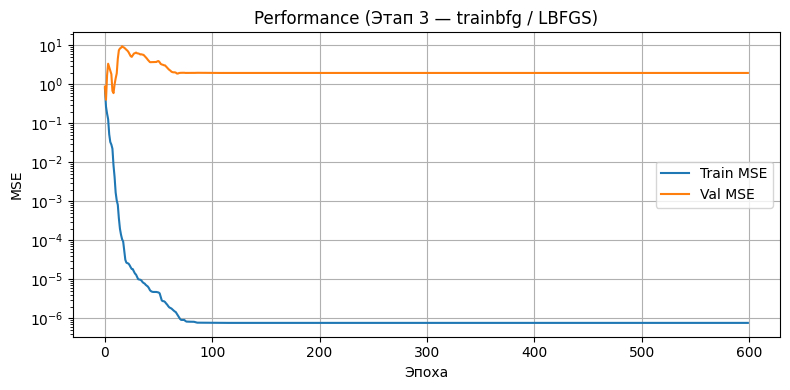

In [18]:
print(f"Эпох обучения:       {len(hist_tr3)}")
print(f"Финальная MSE train: {hist_tr3[-1]:.6e}")
print(f"Финальная MSE val:   {hist_vl3[-1]:.6e}")
print()
print("--- Весовые коэффициенты ---")
for name, param in model_bfg.named_parameters():
    print(f"{name}: shape={list(param.shape)}")
    print(param.data.numpy().round(4))
    print()

# Performance
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hist_tr3, label='Train MSE')
ax.semilogy(hist_vl3, label='Val MSE')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE')
ax.set_title('Performance (Этап 3 — trainbfg / LBFGS)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 3.7–3.8 Оценка качества аппроксимации

Обучающее:
  MSE = 7.655516e-07
  MAE = 7.711220e-04
  Max|err| = 2.797961e-03
  R²  = 0.999998

Контрольное:
  MSE = 1.950735e+00
  MAE = 1.027250e+00
  Max|err| = 2.877918e+00
  R²  = -6.796735


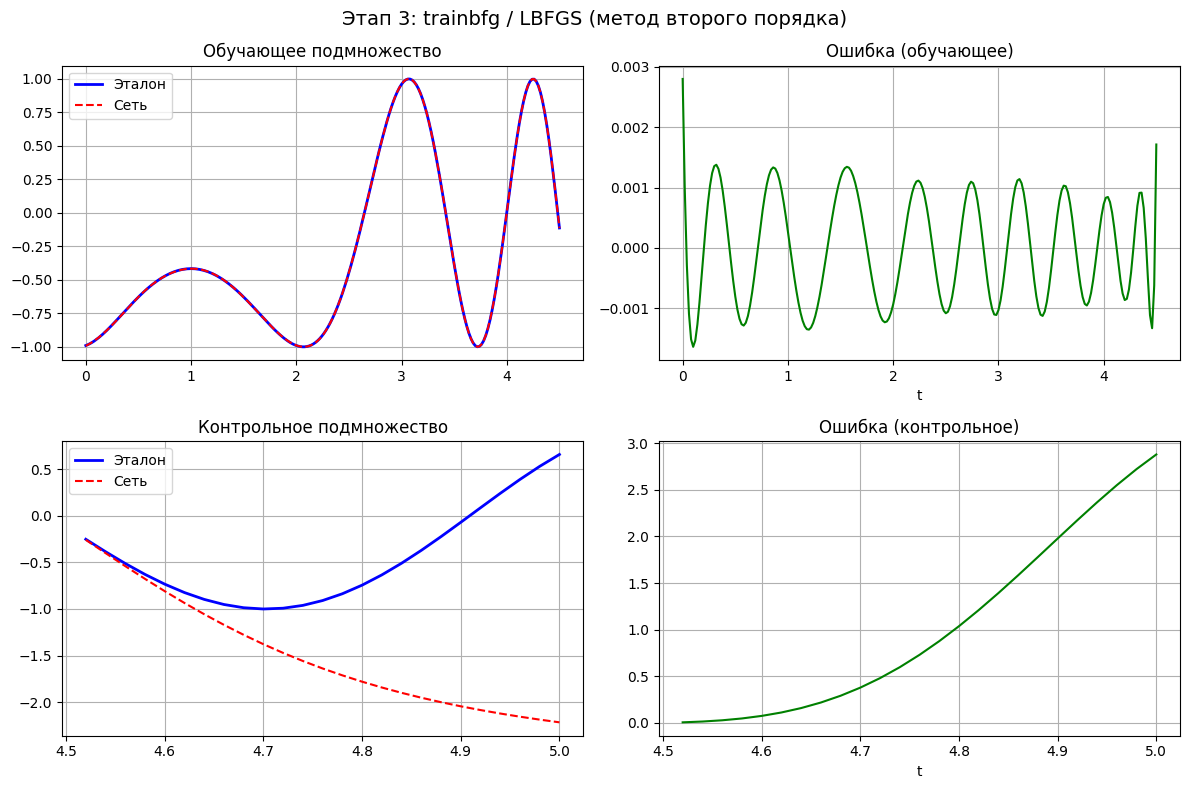

In [19]:
# Обучающее подмножество
pred_tr3, err_tr3 = evaluate_approx(model_bfg, X_train_f, Y_train_f, "Обучающее")
print()
# Контрольное подмножество
pred_vl3, err_vl3 = evaluate_approx(model_bfg, X_val_f, Y_val_f, "Контрольное")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(t_train, y_train_f, 'b-', linewidth=2, label='Эталон')
axes[0, 0].plot(t_train, pred_tr3, 'r--', linewidth=1.5, label='Сеть')
axes[0, 0].set_title('Обучающее подмножество')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(t_train, err_tr3, 'g-')
axes[0, 1].set_title('Ошибка (обучающее)')
axes[0, 1].set_xlabel('t')
axes[0, 1].grid(True)

axes[1, 0].plot(t_val, y_val_f, 'b-', linewidth=2, label='Эталон')
axes[1, 0].plot(t_val, pred_vl3, 'r--', linewidth=1.5, label='Сеть')
axes[1, 0].set_title('Контрольное подмножество')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(t_val, err_vl3, 'g-')
axes[1, 1].set_title('Ошибка (контрольное)')
axes[1, 1].set_xlabel('t')
axes[1, 1].grid(True)

plt.suptitle('Этап 3: trainbfg / LBFGS (метод второго порядка)', fontsize=14)
plt.tight_layout()
plt.show()

### Сравнение методов аппроксимации

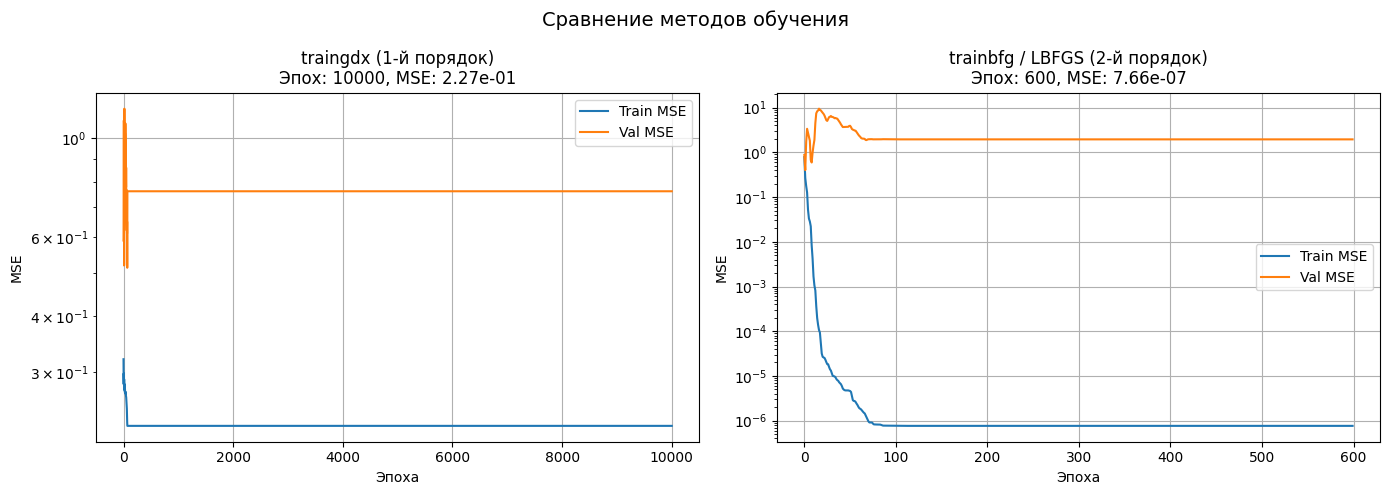

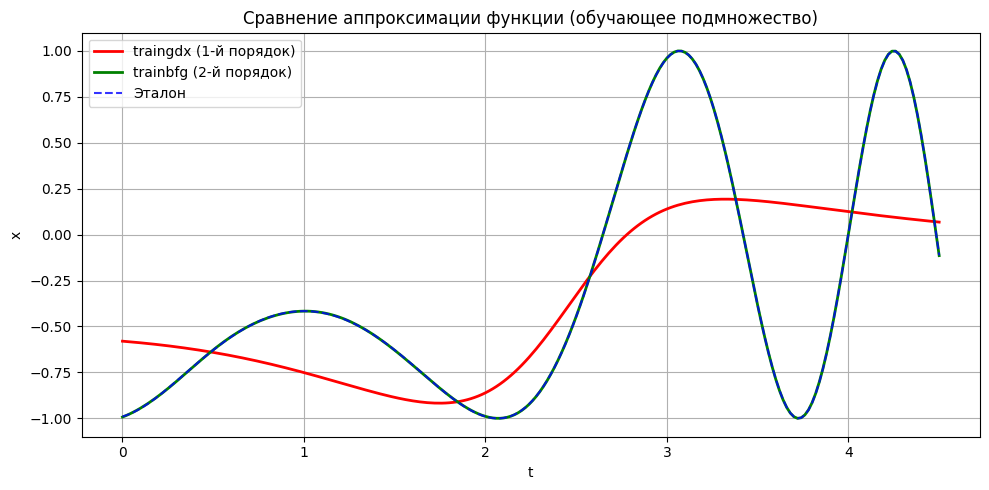

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Этап 2
axes[0].semilogy(hist_tr2, label='Train MSE')
axes[0].semilogy(hist_vl2, label='Val MSE')
axes[0].set_title(f'traingdx (1-й порядок)\nЭпох: {len(hist_tr2)}, MSE: {hist_tr2[-1]:.2e}')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

# Этап 3
axes[1].semilogy(hist_tr3, label='Train MSE')
axes[1].semilogy(hist_vl3, label='Val MSE')
axes[1].set_title(f'trainbfg / LBFGS (2-й порядок)\nЭпох: {len(hist_tr3)}, MSE: {hist_tr3[-1]:.2e}')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Сравнение методов обучения', fontsize=14)
plt.tight_layout()
plt.show()

# Сравнение на одном графике
fig, ax = plt.subplots(figsize=(10, 5))

# Сначала traingdx и trainbfg, потом эталон поверх пунктиром
ax.plot(t_train, pred_tr2, 'r-', linewidth=2, label='traingdx (1-й порядок)')
ax.plot(t_train, pred_tr3, 'g-', linewidth=2, label='trainbfg (2-й порядок)')
ax.plot(t_train, y_train_f, 'b--', linewidth=1.5, label='Эталон', alpha=0.8)
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title('Сравнение аппроксимации функции (обучающее подмножество)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()